# Research 04 — Sector Rotation: Which Sectors Lead and Lag?

## Hypothesis
- **H0:** All sectors move independently — there's no predictable rotation.
- **H1:** Certain sectors consistently lead the market while others lag.
  Relative strength between sectors is persistent enough to exploit.

## Background
Sector rotation is the idea that money flows from sector to sector across the
economic cycle:
- **Early expansion:** Financials, Consumer Discretionary, Tech
- **Mid expansion:** Industrials, Materials
- **Late expansion:** Energy
- **Recession:** Utilities, Healthcare, Consumer Staples

## Approach
1. Download SPDR Sector ETFs + SPY benchmark
2. Compute relative strength vs SPY
3. Correlation matrix: which sectors move together?
4. Test: does sector relative momentum persist?
5. Regime analysis: bull vs bear market
6. Simple sector rotation backtest
7. Conclude

---


In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import yfinance as yf

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)
print('Libraries loaded.')


Libraries loaded.


## 1. Download Sector ETF Data


In [2]:
SECTORS = {
    'XLK': 'Technology',
    'XLF': 'Financials',
    'XLE': 'Energy',
    'XLV': 'Healthcare',
    'XLY': 'Consumer Disc.',
    'XLP': 'Consumer Staples',
    'XLI': 'Industrials',
    'XLB': 'Materials',
    'XLRE': 'Real Estate',
    'XLU': 'Utilities',
    'XLC': 'Communication',
}

tickers = list(SECTORS.keys()) + ['SPY']
START = '2010-01-01'
END = '2024-12-31'

raw = yf.download(tickers, start=START, end=END, auto_adjust=True, progress=False)
prices = raw['Close'].dropna(axis=1, how='all').ffill()

print(f'Downloaded {prices.shape[1]} ETFs | {prices.shape[0]} days')
print(f'Period: {prices.index[0].date()} -> {prices.index[-1].date()}')
prices.tail(3)


Downloaded 12 ETFs | 3773 days
Period: 2010-01-04 -> 2024-12-30


Ticker,SPY,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,,
2024-12-26,589.7539,41.3354,96.9656,40.1231,47.8506,131.3917,119.1701,76.1049,38.5799,36.3322,135.5069,115.0827
2024-12-27,583.5458,41.1127,96.1040,40.1183,47.4998,130.4130,117.5857,75.7324,38.2684,36.2274,134.8759,113.1811
2024-12-30,576.8867,40.5609,95.0956,40.1136,47.0419,129.1017,116.0905,74.8443,38.0891,36.0750,133.2160,111.3632


## 2. Performance Overview


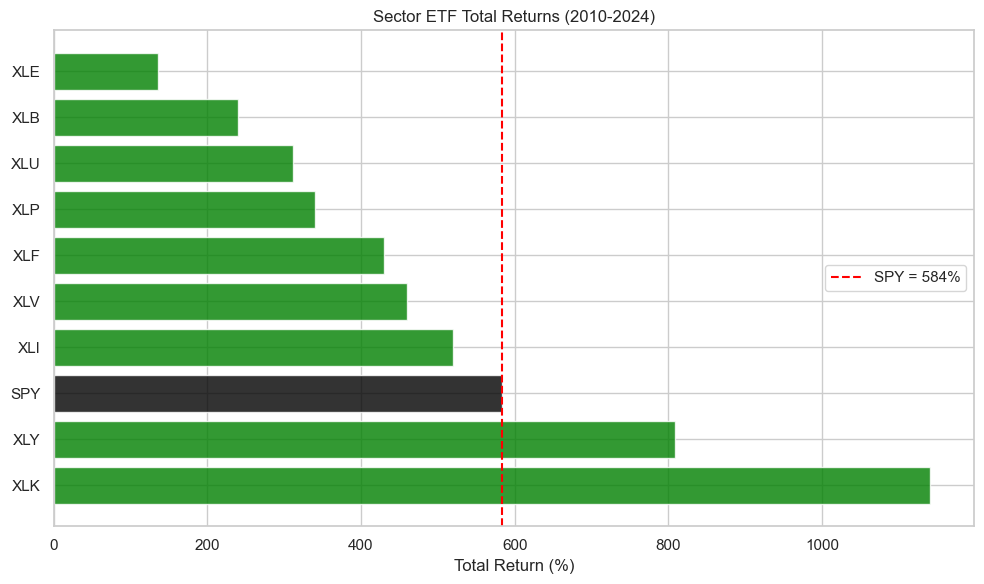

Annualised Volatility:
  XLE   (Energy            ):  27.4%
  XLC   (Communication     ):  23.1%
  XLF   (Financials        ):  22.1%
  XLK   (Technology        ):  21.3%
  XLRE  (Real Estate       ):  20.9%
  XLB   (Materials         ):  20.9%
  XLY   (Consumer Disc.    ):  20.1%
  XLI   (Industrials       ):  19.4%
  XLU   (Utilities         ):  17.6%
  SPY   (Benchmark         ):  17.1%
  XLV   (Healthcare        ):  16.1%
  XLP   (Consumer Staples  ):  13.7%


In [3]:
# Total return over entire period
total_returns = (prices.iloc[-1] / prices.iloc[0] - 1) * 100
total_returns = total_returns.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if t != 'SPY' else 'black' for t in total_returns.index]
ax.barh(total_returns.index, total_returns.values, color=colors, alpha=0.8)
ax.axvline(total_returns['SPY'], color='red', ls='--', lw=1.5, label=f'SPY = {total_returns["SPY"]:.0f}%')
ax.set_xlabel('Total Return (%)')
ax.set_title(f'Sector ETF Total Returns ({START[:4]}-{END[:4]})')
ax.legend()
plt.tight_layout()
plt.show()

# Annualised volatility
ann_vol = prices.pct_change().std() * np.sqrt(252) * 100
print('Annualised Volatility:')
for t in ann_vol.sort_values(ascending=False).index:
    label = SECTORS.get(t, 'Benchmark')
    print(f'  {t:5s} ({label:18s}): {ann_vol[t]:5.1f}%')


## 3. Correlation Matrix — Which Sectors Move Together?

Sectors with low correlation offer diversification.
Sectors with high correlation should not both be overweighted.


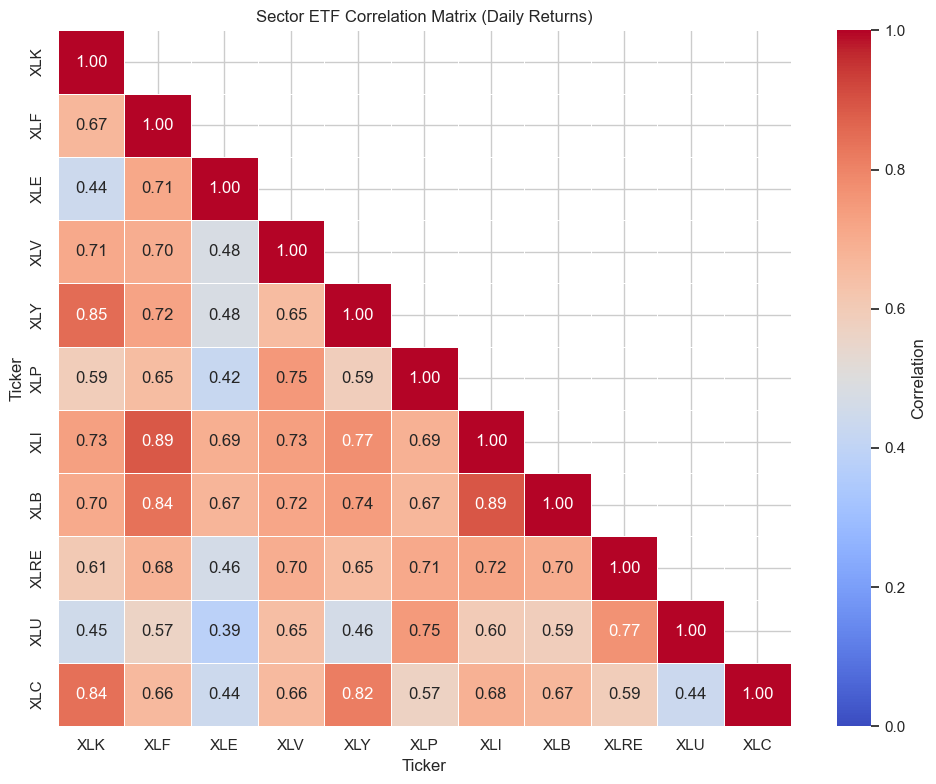

Most diversifying pairs:
Sector 1 Sector 2   Corr
     XLE      XLU 0.3857
     XLE      XLP 0.4221
     XLU      XLC 0.4370
     XLK      XLE 0.4392
     XLE      XLC 0.4393

Most correlated pairs:
Sector 1 Sector 2   Corr
     XLF      XLB 0.8386
     XLK      XLC 0.8406
     XLK      XLY 0.8480
     XLF      XLI 0.8878
     XLI      XLB 0.8916


In [4]:
# Daily returns for sector ETFs only (exclude SPY)
sector_returns = prices[list(SECTORS.keys())].pct_change().dropna()
corr_matrix = sector_returns.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0.5, linewidths=0.5, ax=ax, vmin=0, vmax=1,
            cbar_kws={'label': 'Correlation'})
ax.set_title('Sector ETF Correlation Matrix (Daily Returns)')
plt.tight_layout()
plt.show()

# Most/least correlated pairs
pairs = []
for i, s1 in enumerate(corr_matrix.columns):
    for j, s2 in enumerate(corr_matrix.columns):
        if i < j:
            pairs.append({'Sector 1': s1, 'Sector 2': s2, 'Corr': corr_matrix.loc[s1, s2]})
pairs_df = pd.DataFrame(pairs).sort_values('Corr')
print('Most diversifying pairs:')
print(pairs_df.head(5).to_string(index=False))
print()
print('Most correlated pairs:')
print(pairs_df.tail(5).to_string(index=False))


## 4. Relative Strength vs SPY

Relative strength = Sector / SPY. If this goes UP, sector outperforms the market.


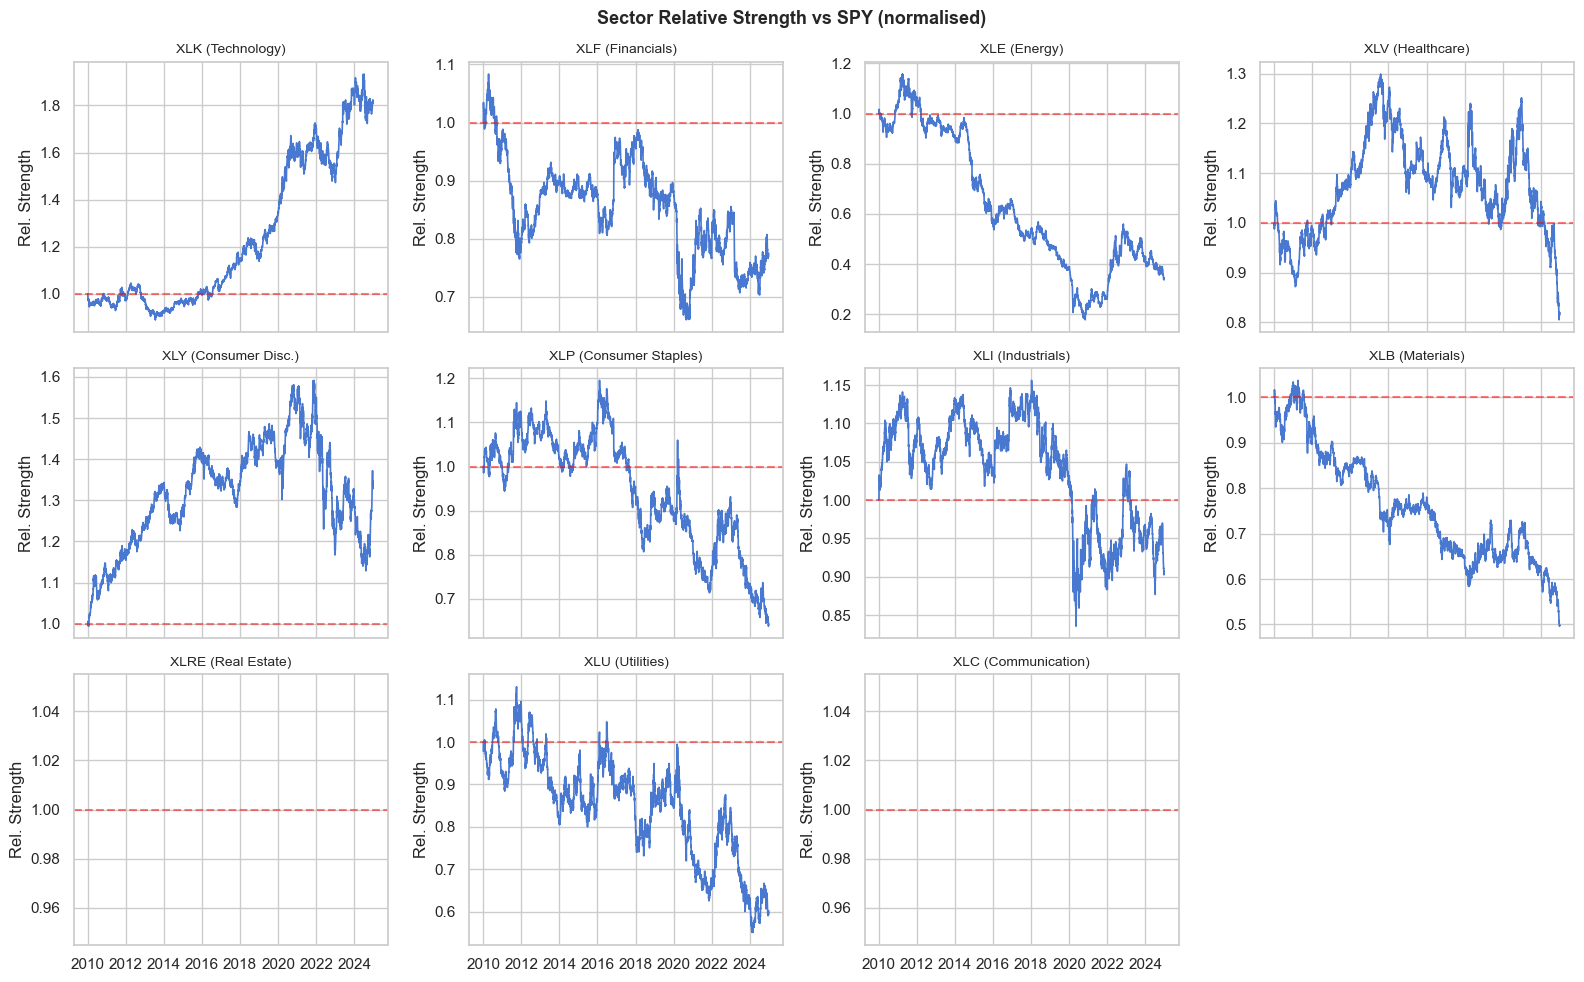

In [5]:
spy = prices['SPY']
rel_strength = prices[list(SECTORS.keys())].div(spy, axis=0)
rel_strength = rel_strength / rel_strength.iloc[0]  # normalise to 1

fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for i, (ticker, name) in enumerate(SECTORS.items()):
    if i >= len(axes):
        break
    ax = axes[i]
    ax.plot(rel_strength.index, rel_strength[ticker].values, lw=1.2)
    ax.axhline(1, color='red', ls='--', alpha=0.5)
    ax.set_title(f'{ticker} ({name})', fontsize=10)
    ax.set_ylabel('Rel. Strength')

# Remove empty subplot
if len(SECTORS) < len(axes):
    for j in range(len(SECTORS), len(axes)):
        fig.delaxes(axes[j])

fig.suptitle('Sector Relative Strength vs SPY (normalised)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Sector Momentum — Is Relative Strength Persistent?

Key question: If a sector outperformed SPY over the past 3 months,
does it continue outperforming over the next month?


In [6]:
# Excess return vs SPY (daily)
spy_ret = spy.pct_change()
sector_ret = prices[list(SECTORS.keys())].pct_change()
excess_ret = sector_ret.sub(spy_ret, axis=0)

# Lookback and holding periods
LOOKBACK = 63  # ~3 months
HOLD = 21      # 1 month forward

past_excess = excess_ret.rolling(LOOKBACK).sum()
fwd_excess = excess_ret.rolling(HOLD).sum().shift(-HOLD)

# Each day, go long top 3 sectors, short bottom 3
ranks = past_excess.rank(axis=1, pct=True)
top_mask = ranks >= 0.73    # top ~3 out of 11
bottom_mask = ranks <= 0.27  # bottom ~3

top_fwd = fwd_excess[top_mask].mean(axis=1).dropna()
bottom_fwd = fwd_excess[bottom_mask].mean(axis=1).dropna()
sector_spread = (top_fwd - bottom_fwd).dropna()

# fwd_excess is a HOLD-day sum computed daily -> overlapping. Subsample to
# non-overlapping windows before the t-test (same fix as NB01).
spread_indep = sector_spread.iloc[::HOLD].dropna()
print('Sector Momentum Spread (Top 3 - Bottom 3, non-overlapping):')
t, p = stats.ttest_1samp(spread_indep, 0)
sharpe = spread_indep.mean() / spread_indep.std() * np.sqrt(252 / HOLD)
print(f'  Mean  : {spread_indep.mean()*100:+.3f}%')
print(f'  t-stat: {t:.3f}')
print(f'  p-val : {p:.4g}  {"SIGNIFICANT" if p < 0.05 else "NOT significant"}')
print(f'  Sharpe: {sharpe:.2f}')


Sector Momentum Spread (Top 3 - Bottom 3, non-overlapping):
  Mean  : -0.066%
  t-stat: -0.202
  p-val : 0.8405  NOT significant
  Sharpe: -0.05


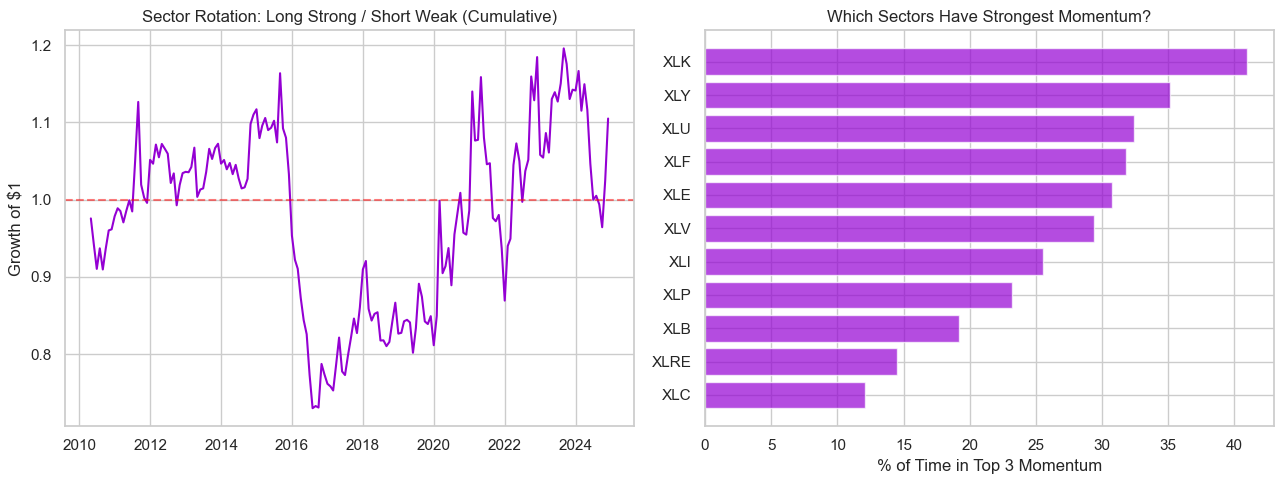

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Cumulative sector rotation spread (monthly non-overlapping)
ax = axes[0]
spread_monthly = sector_spread.resample('ME').last().dropna()
cum = (1 + spread_monthly).cumprod()
ax.plot(cum.index, cum.values, color='darkviolet', lw=1.5)
ax.axhline(1, color='red', ls='--', alpha=0.5)
ax.set_title('Sector Rotation: Long Strong / Short Weak (Cumulative)')
ax.set_ylabel('Growth of $1')

# Which sectors were top momentum most often?
ax = axes[1]
top_count = top_mask.sum() / top_mask.count()
top_count = top_count.sort_values(ascending=True)
ax.barh(top_count.index, top_count.values * 100, color='darkviolet', alpha=0.7)
ax.set_xlabel('% of Time in Top 3 Momentum')
ax.set_title('Which Sectors Have Strongest Momentum?')

plt.tight_layout()
plt.show()


## 6. Sector Regime Analysis — What Works When?

During recessions, defensive sectors (Utilities, Staples, Healthcare)
should outperform. During expansions, cyclical sectors (Tech, Disc., Financials) lead.


In [8]:
# Define bull/bear regime using SPY 200-day SMA
spy_sma200 = spy.rolling(200).mean()
bull_market = spy > spy_sma200
bear_market = ~bull_market

# Annualised return by sector in bull vs bear
results = []
for ticker, name in SECTORS.items():
    s_ret = sector_ret[ticker]
    bull_ret = s_ret[bull_market.reindex(s_ret.index, fill_value=False)].mean() * 252 * 100
    bear_ret = s_ret[bear_market.reindex(s_ret.index, fill_value=False)].mean() * 252 * 100
    results.append({'Sector': ticker, 'Name': name, 'Bull Ann%': bull_ret, 'Bear Ann%': bear_ret,
                    'Spread': bull_ret - bear_ret})

regime_df = pd.DataFrame(results).sort_values('Bear Ann%', ascending=False)
print(regime_df.to_string(index=False))


Sector             Name  Bull Ann%  Bear Ann%  Spread
   XLU        Utilities    14.1068    -1.5733 15.6802
   XLP Consumer Staples    15.1085    -6.4590 21.5675
   XLE           Energy    14.7001   -11.5229 26.2230
   XLI      Industrials    21.0519   -14.0946 35.1465
   XLV       Healthcare    20.1718   -17.0038 37.1755
   XLB        Materials    17.8761   -20.0418 37.9179
   XLY   Consumer Disc.    26.1215   -21.1125 47.2340
   XLK       Technology    29.4491   -22.8057 52.2548
  XLRE      Real Estate    17.1237   -29.3979 46.5216
   XLF       Financials    25.6209   -35.0856 60.7064
   XLC    Communication    28.7501   -42.0199 70.7700


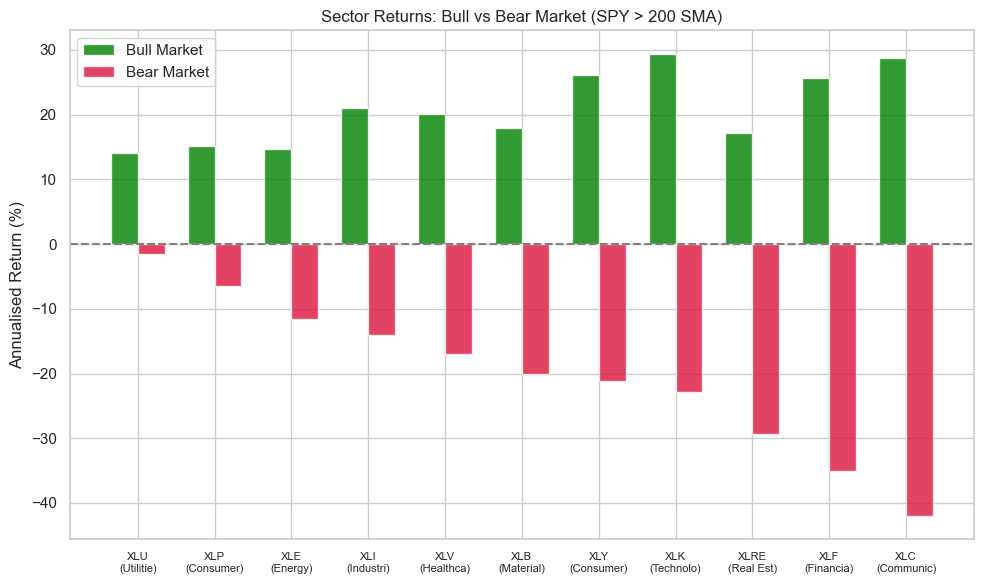


Best defensive sectors (lowest Bear loss):
  XLU (Utilities): -1.6%
  XLP (Consumer Staples): -6.5%


In [9]:
# Grouped bar chart: bull vs bear return per sector
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(regime_df))
width = 0.35
ax.bar(x - width/2, regime_df['Bull Ann%'], width, label='Bull Market', color='green', alpha=0.8)
ax.bar(x + width/2, regime_df['Bear Ann%'], width, label='Bear Market', color='crimson', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"{r['Sector']}\n({r['Name'][:8]})" for _, r in regime_df.iterrows()],
                   fontsize=8, rotation=0)
ax.set_ylabel('Annualised Return (%)')
ax.set_title('Sector Returns: Bull vs Bear Market (SPY > 200 SMA)')
ax.legend()
ax.axhline(0, color='gray', ls='--')
plt.tight_layout()
plt.show()

print()
print('Best defensive sectors (lowest Bear loss):')
print(f'  {regime_df.iloc[0]["Sector"]} ({regime_df.iloc[0]["Name"]}): {regime_df.iloc[0]["Bear Ann%"]:+.1f}%')
print(f'  {regime_df.iloc[1]["Sector"]} ({regime_df.iloc[1]["Name"]}): {regime_df.iloc[1]["Bear Ann%"]:+.1f}%')


## 7. Simple Sector Rotation Strategy (Backtest Preview)

Strategy: Each month, overweight top 3 sectors by 3-month relative momentum.
Compare against equal-weight benchmark.


In [10]:
# Monthly rebalance simulation
monthly_dates = excess_ret.resample('ME').last().index
monthly_dates = monthly_dates[monthly_dates >= excess_ret.index[LOOKBACK]]

rotation_returns = []

for i in range(len(monthly_dates) - 1):
    date = monthly_dates[i]
    next_date = monthly_dates[i + 1]

    # Signal: past 63d excess return as of rebalance date
    if date not in past_excess.index:
        continue
    signal = past_excess.loc[date].dropna()
    if len(signal) < 5:
        continue

    # Top 3 sectors by momentum
    top_sectors = signal.nlargest(3).index.tolist()

    # Forward return (next month)
    mask = (sector_ret.index > date) & (sector_ret.index <= next_date)
    period_ret = sector_ret.loc[mask]

    if len(period_ret) == 0:
        continue

    # Strategy: equal weight top 3
    strat_ret = period_ret[top_sectors].mean(axis=1).sum()
    # Benchmark: equal weight all sectors
    bench_ret = period_ret.mean(axis=1).sum()

    rotation_returns.append({'date': next_date, 'strategy': strat_ret, 'benchmark': bench_ret})

rot_df = pd.DataFrame(rotation_returns).set_index('date')
rot_df['excess'] = rot_df['strategy'] - rot_df['benchmark']

print(f'Sector Rotation Strategy (monthly rebalance, top 3 sectors):')
print(f'  Total months: {len(rot_df)}')
print(f'  Strategy cumulative: {((1+rot_df["strategy"]).prod() - 1)*100:.1f}%')
print(f'  Benchmark cumulative: {((1+rot_df["benchmark"]).prod() - 1)*100:.1f}%')
print(f'  Excess cumulative: {((1+rot_df["excess"]).prod() - 1)*100:.1f}%')
print(f'  Strategy Sharpe: {rot_df["strategy"].mean()/rot_df["strategy"].std()*np.sqrt(12):.2f}')
print(f'  % months outperform: {(rot_df["excess"] > 0).mean():.1%}')


Sector Rotation Strategy (monthly rebalance, top 3 sectors):
  Total months: 124
  Strategy cumulative: 299.9%
  Benchmark cumulative: 334.0%
  Excess cumulative: -9.2%
  Strategy Sharpe: 0.97
  % months outperform: 51.6%


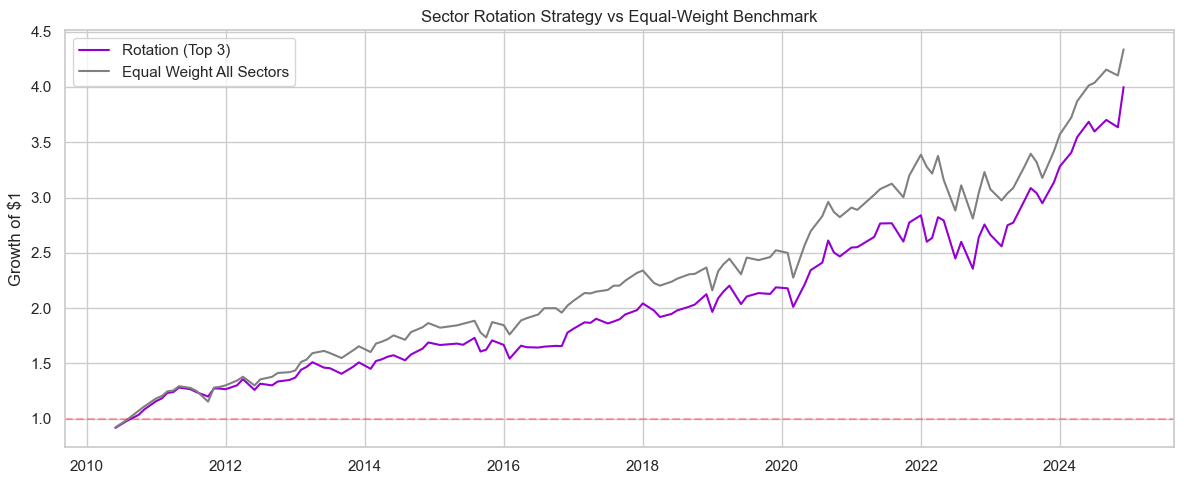

In [11]:
# Equity curves: strategy vs benchmark
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot((1 + rot_df['strategy']).cumprod().index,
        (1 + rot_df['strategy']).cumprod().values,
        color='darkviolet', lw=1.5, label='Rotation (Top 3)')
ax.plot((1 + rot_df['benchmark']).cumprod().index,
        (1 + rot_df['benchmark']).cumprod().values,
        color='gray', lw=1.5, label='Equal Weight All Sectors')
ax.axhline(1, color='red', ls='--', alpha=0.3)
ax.set_title('Sector Rotation Strategy vs Equal-Weight Benchmark')
ax.set_ylabel('Growth of $1')
ax.legend()
plt.tight_layout()
plt.show()


## 8. Conclusion

### Key Findings
| Question | Answer |
|----------|--------|
| Is sector momentum persistent? | *(fill after running)* |
| Sector rotation Sharpe? | *(fill)* |
| Best defensive sectors? | *(fill)* |
| Most correlated pairs? | *(fill)* |
| Most diversifying pairs? | *(fill)* |

### Implications for the Platform
- [ ] Build `SectorRotationStrategy` in `src/strategies/`
- [ ] Add sector ETF data to `MultiAssetManager`
- [ ] Use correlation matrix in `PortfolioOptimizer` for diversification
- [ ] Combine: Sector rotation (macro) + Stock momentum within winning sectors (micro)


In [12]:
# Final summary
print('='*55)
print('       SECTOR ROTATION RESEARCH SUMMARY')
print('='*55)
t_sec, p_sec = stats.ttest_1samp(sector_spread.iloc[::HOLD].dropna(), 0)
sharpe_sec = sector_spread.iloc[::HOLD].dropna().mean() / sector_spread.iloc[::HOLD].dropna().std() * np.sqrt(252/HOLD)
print(f'  Signal             : Long Top 3 / Short Bottom 3 sectors')
print(f'  Lookback           : {LOOKBACK} days')
print(f'  Holding            : {HOLD} days')
print(f'  Spread mean        : {sector_spread.mean()*100:+.3f}%')
print(f'  Ann. Sharpe        : {sharpe_sec:.2f}')
print(f'  t-stat             : {t_sec:.3f}')
print(f'  p-value            : {p_sec:.4g}')
print(f'  Rotation strategy  : {((1+rot_df["strategy"]).prod()-1)*100:.1f}% total')
print(f'  vs Benchmark       : {((1+rot_df["benchmark"]).prod()-1)*100:.1f}% total')
print('='*55)
if p_sec < 0.05:
    print('  CONCLUSION: Sector momentum IS significant -> rotation strategy viable.')
else:
    print('  CONCLUSION: Cannot confirm sector momentum at this significance level.')


       SECTOR ROTATION RESEARCH SUMMARY
  Signal             : Long Top 3 / Short Bottom 3 sectors
  Lookback           : 63 days
  Holding            : 21 days
  Spread mean        : -0.011%
  Ann. Sharpe        : -0.05
  t-stat             : -0.202
  p-value            : 0.8405
  Rotation strategy  : 299.9% total
  vs Benchmark       : 334.0% total
  CONCLUSION: Cannot confirm sector momentum at this significance level.
